## Question-1

In [159]:
import numpy as np
import matplotlib.pyplot as plt


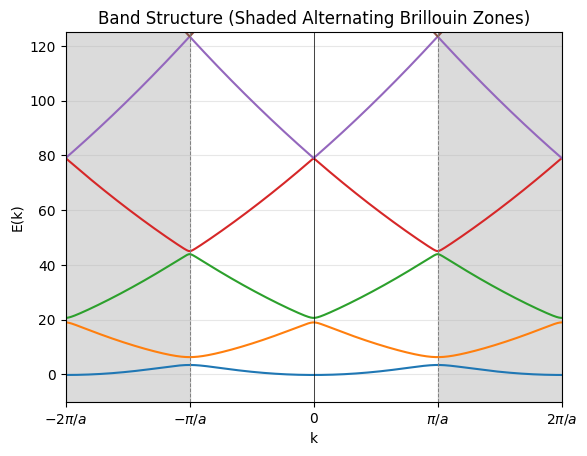

In [180]:
N = 5000
a = 1
h = 1
m = 1
A=3

V = [A/6,A/4,A/2,0,A/2,A/4,A/6]  # V(G) values for G = -3, -2, -1, 0, 1, 2, 3

def create_Hk(k, V, n=3):
    # n = (len(V)-1)//2
    n_harmonics = (len(V)-1)//2
    G_vals = np.array([2*np.pi*i/a for i in range(-n, n+1)])

    # kinetic term
    p = [h**2 * (k + G)**2 / (2*m) for G in G_vals]
    H = np.diag(p)

    # potential term
    for i in range(2*n + 1):
        for j in range(2*n + 1):
            diff = i - j
            if -n_harmonics <= diff <= n_harmonics:
                H[i, j] += V[diff + n_harmonics]

    return H

def plot_band_structure(n=3):
    k_range = np.linspace(-3*np.pi/a, 3*np.pi/a, N)
    
    # n = (len(V)-1)//2
    dim = 2*n + 1

    # Storing the eigenvalues
    bands = [[] for _ in range(dim)]

    for k in k_range:
        H_k = create_Hk(k, V, n)
        eigenvalues = np.linalg.eigvalsh(H_k)
        for i in range(dim):
            bands[i].append(float(eigenvalues[i]))
    return bands
#shading BZ's
k_range = np.linspace(-3*np.pi/a, 3*np.pi/a, N)
bz_edges = np.arange(-2*np.pi/a, 3*np.pi/a, np.pi/a)
bz_edges = bz_edges[bz_edges != 0]
bands =plot_band_structure()
for i in range(len(bz_edges)-1):
    if i % 2 == 0:
        plt.axvspan(bz_edges[i], bz_edges[i+1], 
                    color='lightgray', alpha=0.8)

for band in bands:
    plt.plot(k_range, band)

for edge in bz_edges:
    plt.axvline(edge, linestyle='--', color='gray', linewidth=0.7)
    
plt.axvline(0, linestyle='-', color='black', linewidth=0.5)

plt.xlabel('k')
plt.ylabel('E(k)')
plt.title('Band Structure (Shaded Alternating Brillouin Zones)')
plt.xlim(-2*np.pi/a, 2*np.pi/a)
plt.ylim(-10,125)

plt.xticks(
    np.arange(-2*np.pi/a, 3*np.pi/a, np.pi/a),
    [r'$-2\pi/a$', r'$-\pi/a$', '0', r'$\pi/a$', r'$2\pi/a$']
)
    
plt.grid(alpha=0.3)
plt.show()



## Question-2

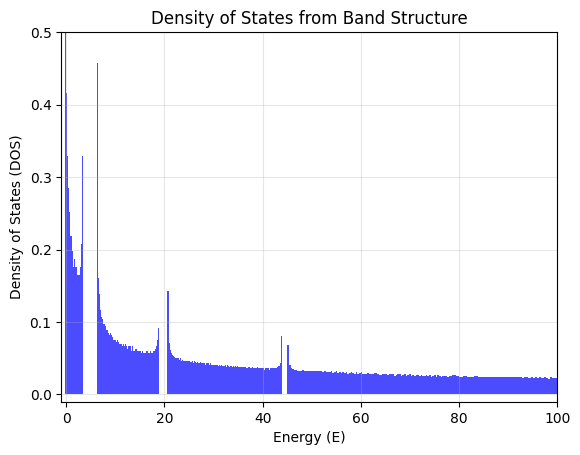

In [161]:
Bands = plot_band_structure()
#to obtain density of states, we can use the eigenvalues stored in Bands to create a histogram to visualize the density of states.
def plot_density_of_states(bands):
    # all_eigenvalues = np.concatenate(bands)
    for band in bands:
        plt.hist(band, bins=100, density=True, alpha=0.7, color='blue')
    
# plt.figure(figsize=(6, 8))
plot_density_of_states(Bands)
plt.xlabel('Energy (E)')
plt.ylabel('Density of States (DOS)')
plt.title('Density of States from Band Structure')
plt.grid(alpha=0.3)
plt.ylim(-0.01,0.5)
plt.xlim(-1,100)
plt.show()

## Question - 3

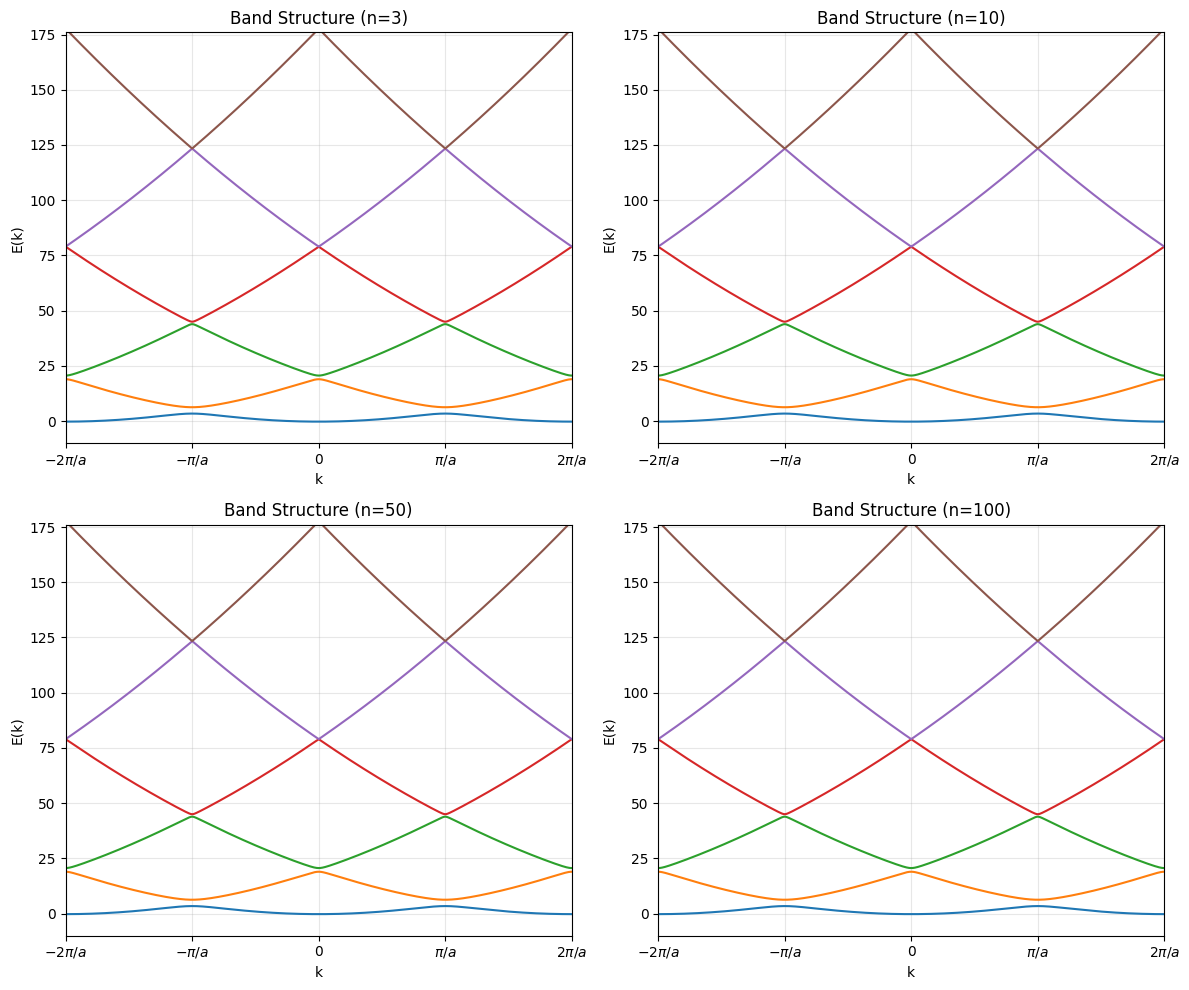

In [181]:
n_list = [3, 10, 50,100]
# Creating a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  

for i, n in enumerate(n_list):
    ax = axes[i]
    V = [A/6, A/4, A/2, 0, A/2, A/4, A/6]
    bands = plot_band_structure(n) 
    
    for band in bands:
        ax.plot(k_range, band)
    
    # Subplot styling
    ax.set_xlabel('k')
    ax.set_ylabel('E(k)')
    ax.set_title(f'Band Structure (n={n})')
    ax.set_xlim(-2*np.pi/a, 2*np.pi/a)
    ax.set_ylim(-10, 176)
    
    # Setting the Ticks
    ax.set_xticks(
        np.arange(-2*np.pi/a, 3*np.pi/a, np.pi/a)
    )
    ax.set_xticklabels([r'$-2\pi/a$', r'$-\pi/a$', '0', r'$\pi/a$', r'$2\pi/a$'])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Question - 4

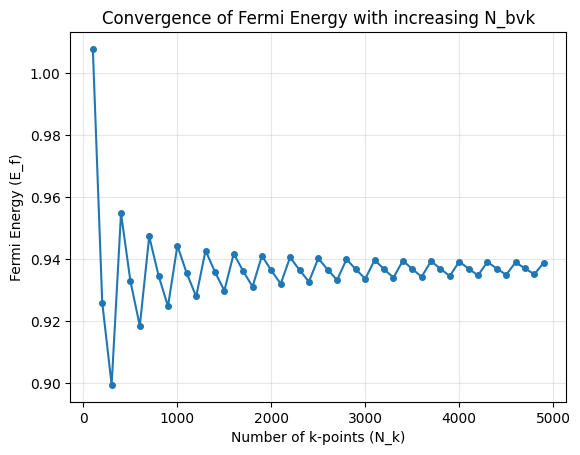

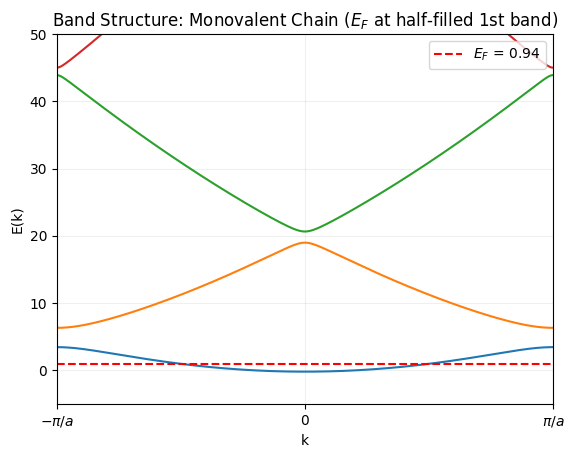

In [167]:
def get_bands(n=3,N_k=N):
    k_range = np.linspace(-3*np.pi/a, 3*np.pi/a, N_k)
    dim = 2*n + 1
    bands = np.zeros((dim, N_k))
    for idx, k in enumerate(k_range):
        H_k = create_Hk(k, V, n)
        eigenvalues = np.linalg.eigvalsh(H_k)
        bands[:, idx] = eigenvalues
        #Fermi level index
        k_fermi_idx = np.argmin(np.abs(k_range - (np.pi / (2 * a))))
        #Fermi energy
        E_f = bands[0][k_fermi_idx] 
    return k_range, bands, E_f

#-----------------Plotting convergence of Fermi energy with k-point sampling
N_k_vals = np.arange(100,5000,100)
E_f_values = []
for i in N_k_vals:  
    E_f_temp = get_bands(n=3,N_k=i)
    E_f_values.append(E_f_temp[2])
    
plt.plot(N_k_vals, E_f_values, marker='o',markersize=4)
plt.xlabel('Number of k-points (N_k)')
plt.ylabel('Fermi Energy (E_f)')
plt.title('Convergence of Fermi Energy with increasing N_bvk')
plt.grid(alpha=0.3)
plt.show()
k_fermi_idx = int(np.argmin(np.abs(k_range - (np.pi / (2 * a)))))
E_f = bands[0][k_fermi_idx] 


#-----------------Plotting the femi level for N_bvk = 5000
k_range, bands, E_f = get_bands(n=3,N_k=5000)
# Plotting Bands
for i, band in enumerate(bands):
    plt.plot(k_range, band)

#marking fermi level
plt.axhline(E_f, color='red', linestyle='--', linewidth=1.5, label=f'$E_F$ = {E_f:.2f}')

plt.xlabel('k')
plt.ylabel('E(k)')
plt.title(f'Band Structure: Monovalent Chain ($E_F$ at half-filled 1st band)')
plt.xlim(-np.pi/a, np.pi/a)
plt.ylim(-5, 50) 
plt.xticks(
    np.arange(-np.pi/a, 2*np.pi/a, np.pi/a),
    [r'$-\pi/a$', '0', r'$\pi/a$']
)
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.show()

## Question - 5 

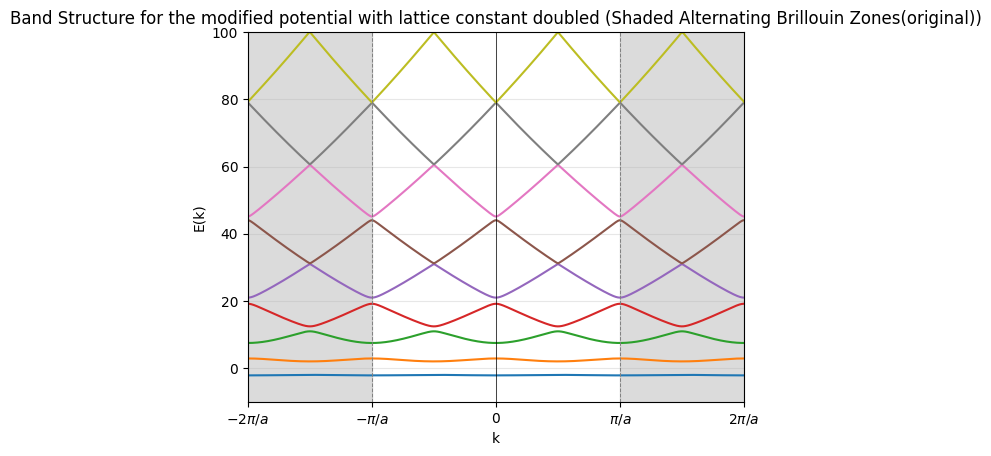

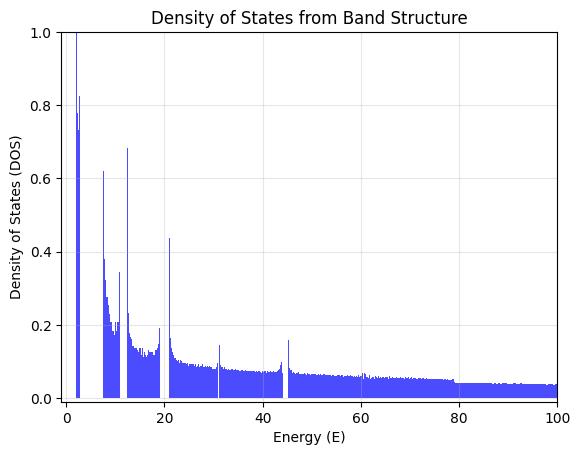

In [182]:
# This is equivalent to doubling the initial value of a and changing the potential harmonics accordingly

N = 5000
a_new = 2 #doubled the lattice constant
h = 1
m = 1
A=3

V = [A/6,0,A/4,0,A/2,A,0,A,A/2,0,A/4,0,A/6]  # potenial harmonics changed accordingly

def create_Hk(k, V, n=6):
    # n = (len(V)-1)//2
    n_harmonics = (len(V)-1)//2
    G_vals = np.array([2*np.pi*i/a_new for i in range(-n, n+1)])

    # kinetic term
    p = [h**2 * (k + G)**2 / (2*m) for G in G_vals]
    H = np.diag(p)

    # potential term
    for i in range(2*n + 1):
        for j in range(2*n + 1):
            diff = i - j
            if -n_harmonics <= diff <= n_harmonics:
                H[i, j] += V[diff + n_harmonics]

    return H

def plot_band_structure(n=6):
    k_range = np.linspace(-6*np.pi/a_new, 6*np.pi/a_new, N)
    
    # n = (len(V)-1)//2
    dim = 2*n + 1

    # Storing the eigenvalues
    bands = [[] for _ in range(dim)]

    for k in k_range:
        H_k = create_Hk(k, V, n)
        eigenvalues = np.linalg.eigvalsh(H_k)
        for i in range(dim):
            bands[i].append(float(eigenvalues[i]))
    return bands
#shading BZ's
k_range = np.linspace(-6*np.pi/a_new, 6*np.pi/a_new, N)
bz_edges = np.arange(-2*np.pi, 3*np.pi, np.pi)
bz_edges = bz_edges[bz_edges != 0]
new_bands =plot_band_structure()
for i in range(len(bz_edges)-1):
    if i % 2 == 0:
        plt.axvspan(bz_edges[i], bz_edges[i+1], 
                    color='lightgray', alpha=0.8)

for band in new_bands:
    plt.plot(k_range, band)

for edge in bz_edges:
    plt.axvline(edge, linestyle='--', color='gray', linewidth=0.7)
    
plt.axvline(0, linestyle='-', color='black', linewidth=0.5)

plt.xlabel('k')
plt.ylabel('E(k)')
plt.title('Band Structure for the modified potential with lattice constant doubled (Shaded Alternating Brillouin Zones(original))')
plt.xlim(-2*np.pi, 2*np.pi)
plt.ylim(-10,100)

plt.xticks(
    np.arange(-2*np.pi, 3*np.pi, np.pi),
    [r'$-2\pi/a$', r'$-\pi/a$', '0', r'$\pi/a$', r'$2\pi/a$']
)
    
plt.grid(alpha=0.3)
plt.show()

plot_density_of_states(new_bands)
plt.xlabel('Energy (E)')
plt.ylabel('Density of States (DOS)')
plt.title('Density of States from Band Structure')
plt.grid(alpha=0.3)
plt.ylim(-0.01,1)
plt.xlim(-1,100)
plt.show()

## Question - 6

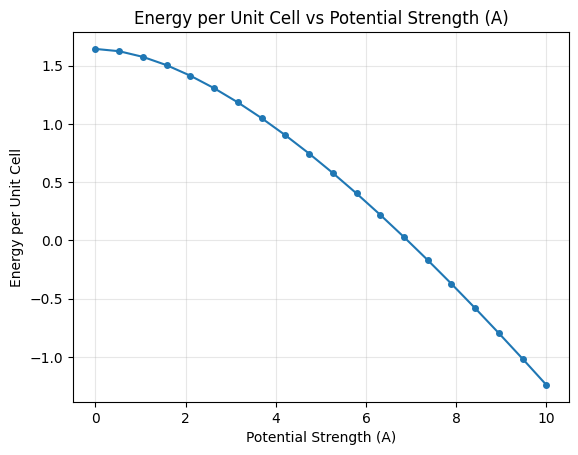

In [184]:
# Computing the energy per unit cell for original potential
N = 5000
a = 1
h = 1
m = 1
A=3

def compute_energy_per_cell(n=6,A=3):
    V = [A/6,A/4,A/2,0,A/2,A/4,A/6]  # V(G) values for G = -3, -2, -1, 0, 1, 2, 3

    def create_Hk(k, V, n=3):
        # n = (len(V)-1)//2
        n_harmonics = (len(V)-1)//2
        G_vals = np.array([2*np.pi*i/a for i in range(-n, n+1)])

        # kinetic term
        p = [h**2 * (k + G)**2 / (2*m) for G in G_vals]
        H = np.diag(p)

        # potential term
        for i in range(2*n + 1):
            for j in range(2*n + 1):
                diff = i - j
                if -n_harmonics <= diff <= n_harmonics:
                    H[i, j] += V[diff + n_harmonics]

        return H
    
    k_range = np.linspace(-6*np.pi/a, 6*np.pi/a, N)
    
    # n = (len(V)-1)//2
    dim = 2*n + 1

    # Storing the eigenvalues
    bands = [[] for _ in range(dim)]

    for k in k_range:
        H_k = create_Hk(k, V, n)
        eigenvalues = np.linalg.eigvalsh(H_k)
        for i in range(dim):
            bands[i].append(float(eigenvalues[i]))
    return bands
A_vals = np.linspace(0, 10, 20)
E_per_cell_values = []
for A in A_vals:
    bands = compute_energy_per_cell(n=6,A=A)
    band = bands[0]  
    E_per_cell = np.mean(band[:N//2])  # Average energy of the occupied states
    # print(f"A={A}, Energy per cell={E_per_cell}")
    E_per_cell_values.append(E_per_cell)
plt.plot(A_vals, E_per_cell_values, marker='o', markersize=4)
plt.xlabel('Potential Strength (A)')
plt.ylabel('Energy per Unit Cell')
plt.title('Energy per Unit Cell vs Potential Strength (A)')
plt.grid(alpha=0.3)
plt.show()